# COMP6200: Data Science
## Portfolio 4: Heart Disease Prediction

In [845]:
student_name = "Tuan Dat Nguyen"
student_ID = "46233148"

### Introduction
Cardiovascular diseases (CVDs) are the leading global health issue, causing millions of deaths, severe morbidity and disability annually. According to the World Health Organisation (WHO), an estimated 18 million lives are taken each year due to heart and blood vessel disease. While the causality of CVDs is yet unknown widely, identifying those at high risk of CVDs is extremely needed. Early diagnosis and intervention play a crucial role in improving patient outcomes through effective treatment and management and reducing burdens on healthcare systems. To assist healthcare professionals in making more informed decisions, there is a growing demand for AI technologies and machine learning models to predict the likelihood of getting CDVs.

This portfolio aims to explore the [Heart Disease Prediction](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data) dataset, then build different machine learning classification algorithmic models to evaluate and test their predictive performance based on a set of clinical features for CVDs. 

The dataset includes the following 12 columns:

- `Age`: age of the patient
- `Sex`: sex of the patient
- `ChestPainType`: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- `RestingBP`: resting blood pressure [mm Hg]
- `Cholesterol`: serum cholesterol level [mm/dl]
- `FastingBS`: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- `RestingECG`: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- `MaxHR`: maximum heart rate achieved
- `ExerciseAngina`: exercise-induced angina [Y: Yes/ N: No]
- `Oldpeak`: Depression induced by exercise relative to rest = ST
- `ST_Slope`: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- `HeartDisease`: output class [1: having heart disease, 0: Normal]

**Problem Statement**: This project aims to provide an answer due to the following question - *<ins>"How accurately can we determine whether a patient has a cardiovascular disease to ensure they are correctly diagnosed and receive timely care?"</ins>*

### Methodology

The high-level end goal is to build and evaluate predictive models for the target label `HeartDissease` from other available features. The following tasks will be addressed throughout this portfolio:
- Load the dataset, describe all information and perform exploratory data analysis (EDA)
- Clean, preprocess and visualise the dataset accordingly with the target variable
- Split dataset into training and testing data
- Build **Logistic Regression** and **KNN Classifier models** to compare the **accuracy** of their performance to define the best predictive algorithm

## Load the dataset and show all information

In [851]:
#Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_selection import RFE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Turn off the warning
import warnings
warnings.filterwarnings('ignore')

#Import the dataset and show the first 5 rows of the data
data = pd.read_csv('heart.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [852]:
#Provide a rough picture of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


**Comment**: There are a total of 918 values for each of the 11 columns representing clinical features, and they are a max of numerical and categorical.

In [854]:
#Describe the dataset for each particular column
data.describe(include="all")

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


## Task 1: Perform Exploratory Data Analysis (EDA)

### Step 1.1: Check if the dataset has a missing value

In [856]:
data.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

**Comment**: There is not any missing value in this dataset.

### Step 1.2. Check if the dataset has duplicated values

In [859]:
data.duplicated().sum()

0

**Comment**: There is not any duplicated value in the dataset.

### Step 1.3: Data Visualisation

**[a] Distribution of Target Variable** `HeartDisease`

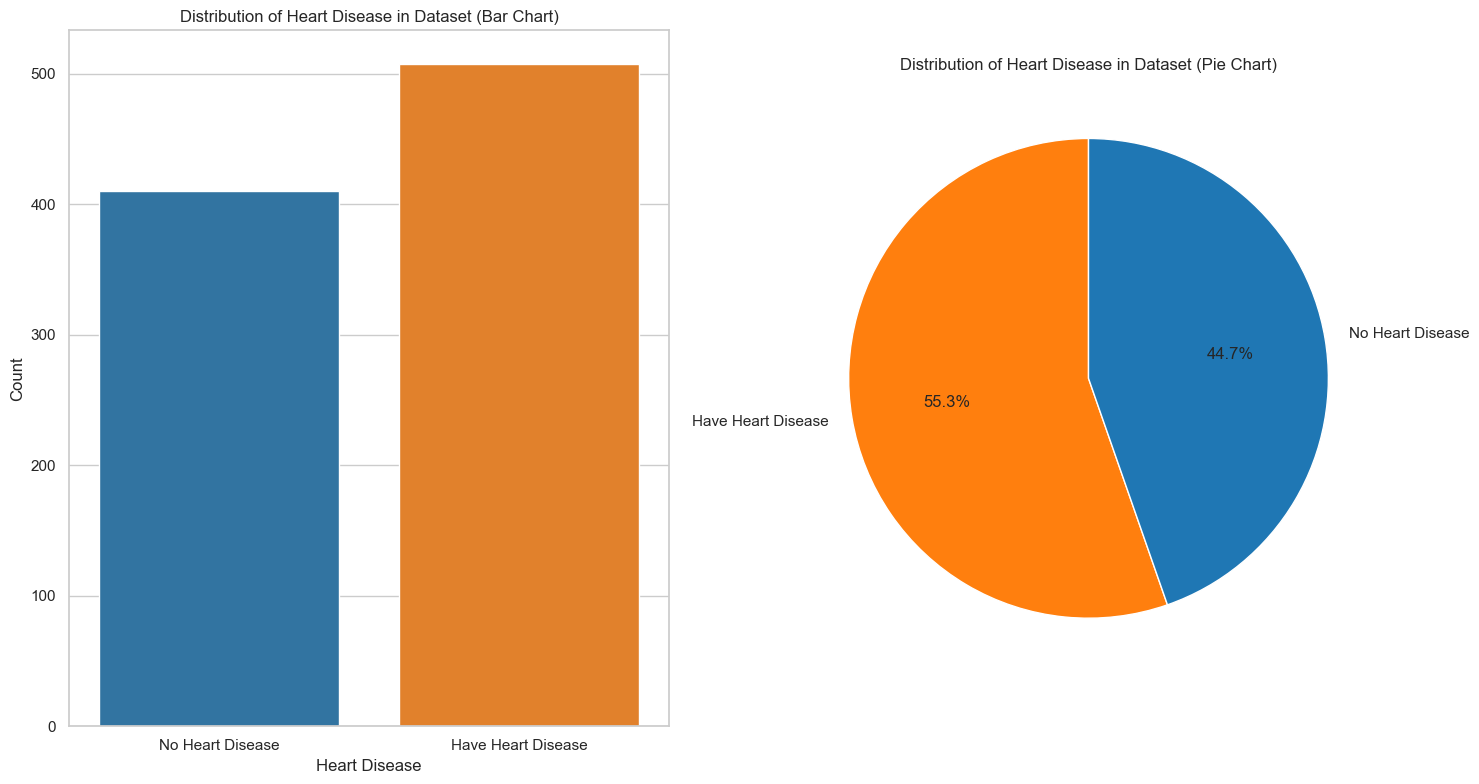

In [863]:
#Set up the visualisation style
sns.set(style="whitegrid")

#Plot the distribution of the 'HeartDisease' target label
plt.figure(figsize=(15, 8))

#Subplot 1: Bar Chart for Heart Disease Distribution
plt.subplot(1, 2, 1)
sns.countplot(x=data['HeartDisease'], palette="tab10")
plt.title('Distribution of Heart Disease in Dataset (Bar Chart)')
plt.xlabel('Heart Disease')
plt.xticks([0, 1], ['No Heart Disease', 'Have Heart Disease'])
plt.ylabel('Count')

#Subplot 2: Pie Chart for Heart Disease Distribution
plt.subplot(1, 2, 2)
heart_disease_counts = data['HeartDisease'].value_counts()
#Reverse the colour palette for the pie chart to match the bar chart
plt.pie(heart_disease_counts, labels=['Have Heart Disease', 'No Heart Disease'], autopct='%1.1f%%', startangle=90, colors = colors[ : :-1])
plt.title('Distribution of Heart Disease in Dataset (Pie Chart)')

#Show the plot
plt.tight_layout()  #Ensure proper spacing between subplots
plt.show()


**Comment**: This visualisation comes from the EDA stage, which provides a preliminary understanding of the class distribution before running any machine learning model. From this dataset, it can be claimed that the data is pretty well-balanced since no one class is skewed extremely. Patients predicted to have heart disease account for 55.3% of the data, compared to those not associated with CDVs at 44.7%. In regards to the total number, slightly above 500 cases are predicted with heart disease and the rest of 400 cases might not have this health issue.

**[b] Define numerical columns and visualise distribution of numerical features**

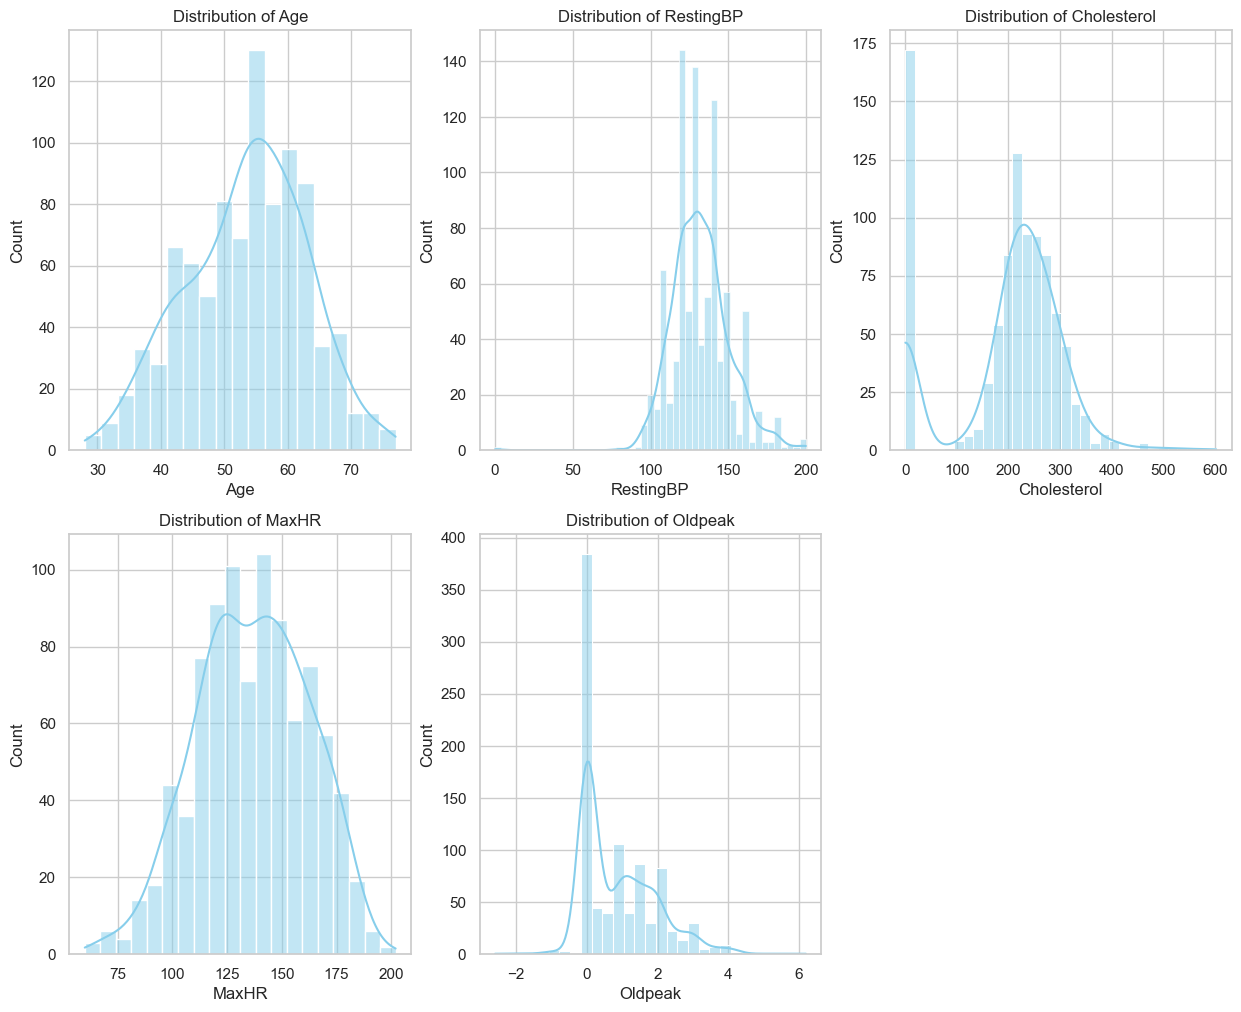

In [866]:
#Define numerical columns
numerical_col = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

#Set up the visualisation style
sns.set(style="whitegrid")

#Create subplots for histograms for each numerical column
plt.figure(figsize=(15, 12))

#Loop through each numerical column and create a subplot for both histogram and boxplot
for i, column in enumerate(numerical_col, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[column], kde=True, color='skyblue')
    plt.title(f'Distribution of {column}')

#Show the plots
plt.show()

**Comment:** From the image above, some characteristics of each feature have been outlined below:
- Regarding `Age`: The distribution appears normal with the bell shape, with the majority of patients clustered around the age of 50 to 60. Patients 55 years old are the highest group with CDVs, while the count significantly decreases for ages below 40 and below 70.
- Regarding `RestingBP`: This distribution is slightly positively right-skewed, demonstrating that most patients' resting blood pressure fluctuates between 120 and 140 mm Hg. A narrow spread between the median and higher outliers towards 200 can also be observed.
- Regarding `Cholesterol`: A bimodal distribution is shown in this feature as there is a significant spike near the '0' value. This indicates abnormal cholesterol data, potentially due to the inability to collect and record this information from the patients. Meanwhile, the second peak is between 200 and 300 mm/dl, with the highest point at 250. It suggests that most patients have this typical cholesterol range.
- Regarding `MaxHR`, the Maximum Heart rate appears to distribute normally, with a slight skew towards the right side. The central tendency ranges between 125 and 150 beats per minute, and only a few patients have very low or high MaxHR than normal.
- Regarding `Oldpeak`: A right-skewed distribution can be observed in the figure for depression induced by exercise relative to rest. The majority of patients have this oldpeak value close to 0, a positive result showing there is little or no ST depression during exercise. However, a small subset of patients experience an index of 2 to 4 and even 6, representing some severe ST depression.

Overall, `Age` and `MaxHR` features have relatively normal distributions, meaning they are well-behaved variables without significant outliers. On the other hand, `RestingBP` and `Oldpeak` exhibit slightly right-skewed distributions, suggesting most patients achieve values in certain ranges while a small group of them may experience outer values. There is a potential data issue in `Cholesterol` since a lot of '0' values were recorded among patients.

**[c] Define categorical features and visualise data**

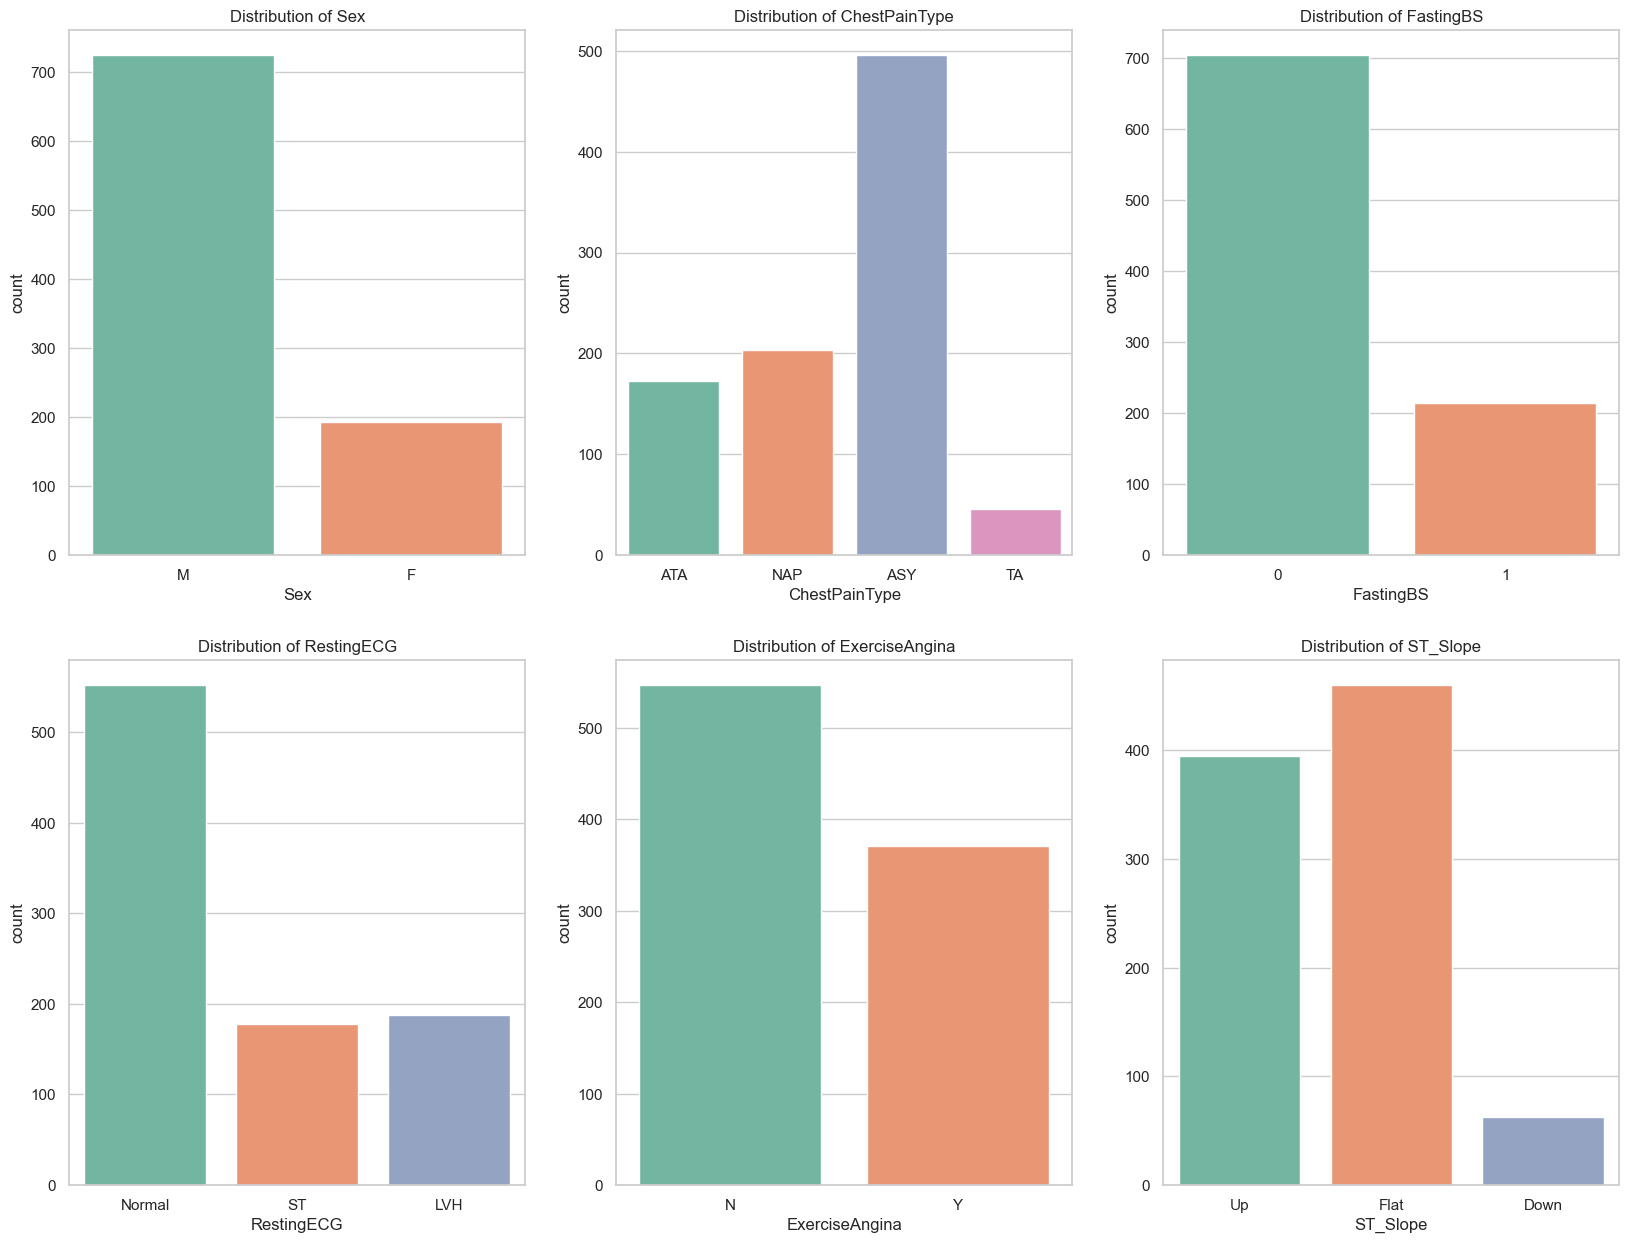

In [869]:
#Define categorical columns
categorical_col = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

#Set up the visualisation style
sns.set(style="whitegrid")

#Create a figure for subplots based on number of features
plt.figure(figsize=(20, 15))

#Loop through each categorical column and create a subplot for the countplot
for i, column in enumerate(categorical_col, 1):  # start index at 1 for subplot
    plt.subplot(2, 3, i)
    sns.countplot(x=data[column], palette="Set2")
    plt.title(f'Distribution of {column}')

#Show the plots
plt.show()

**Comment:** The distribution of various categorical features is described below
- Regarding `Sex`: Male patients are recorded to be more likely to experience CDVs than females, with over 700 cases compared to roughly 200 female samples. A significant gender imbalance is seen in this dataset as it overrepresents male patients.
- Regarding `ChestPainType`: ASY is the most common chest pain type, meaning most patients do not exhibit typical symptoms. There is a higher risk of less obvious CDVs among others. Meanwhile, TA is the least common type.
- Regarding `FastingBS`: Approximately 700 patients have a fasting blood sugar below 120 mg/dL (represented as 0), while only a small group of 200 patients have their FastingBS higher than that benchmark (represented as 1). This indicates that the majority of patients have normal blood sugar levels, while that smaller group tends to be at risk of having CDVs due to their elevated blood sugar.
- Regarding `RestingECG`: A normal reading level is mostly seen in the data, with about 550 patients experiencing this; however, some others show signs of having CDVs, either ST-T wave abnormalities (ST) or left ventricular hypertrophy (LVH).
- Regarding `ExerciseAngina`: Most patients are believed not to experience exercise-induced angina (represented by N), but a significant proportion (approximately 350 patients) do (represented by Y). As this feature is an indicator of more advanced heart disease, it is important to pay attention to such a highly possible threat.
- Regarding `ST_Slope`: The Flat slope is the most common one observed in this dataset as over 450 patients have this symptom, which poses potential risks as these can be associated with heart disease. Meanwhile, the down-slopping ST segment is relatively rare in this group.

Ultimately, the distribution of these categorical features provides a snapshot of the dataset's composition and highlights the presence of some key risk factors leading to heart diseases, such as `FastingBS`, `ExerciseAngina` and `ST_Slope`. This analysis suggests the adjustment of some potential biases by considering **gender imbalance, asymptomatic chest pain type, and resting ECG results,** for example, when building the predictive machine learning model to identify signs of CDVs.

**[d] Insight Visualisation: Finding Relationships between prediction target and other attributes**

*[d.1] Between categorical variable `Sex` and target variable `HeartDisease`*

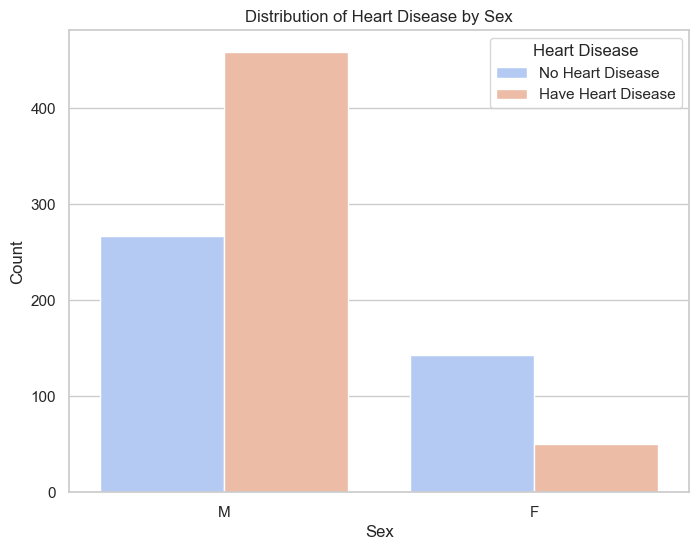

In [873]:
# Set up the visualisation style
sns.set(style="whitegrid")

# Create a count plot for 'Sex' vs 'HeartDisease'
plt.figure(figsize=(8, 6))
sns.countplot(x='Sex', hue='HeartDisease', data=data, palette="coolwarm")

# Add title and labels
plt.title('Distribution of Heart Disease by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
#change the hue labels in the legend
plt.legend(title='Heart Disease', loc='upper right', labels=['No Heart Disease', 'Have Heart Disease'])

# Show the plot
plt.show()

**Comment:** Since this dataset is unbalanced in the record of patients regarding their `Sex`, it is understandable that there is a significant gap between the distribution of males and females with respect to CDVs.
1. Among the men's group, the majority (over 450) have heart diseases, suggesting this health issue is more prevalent in this gender.
2. Contrastingly, a reverse pattern is seen among female patients, with only 50 cases recorded of heart disease in women. This indicates that females are unlikely to have CDVs. A lower prevalence or different risk factors may be associated with this group.

Therefore, **there is a greater risk of males exhibiting heart disease in this population**, while most females are more likely to be without cardiovascular conditions.

*[d.2] Between numerical feature `Age` and target variable `HeartDisease`*

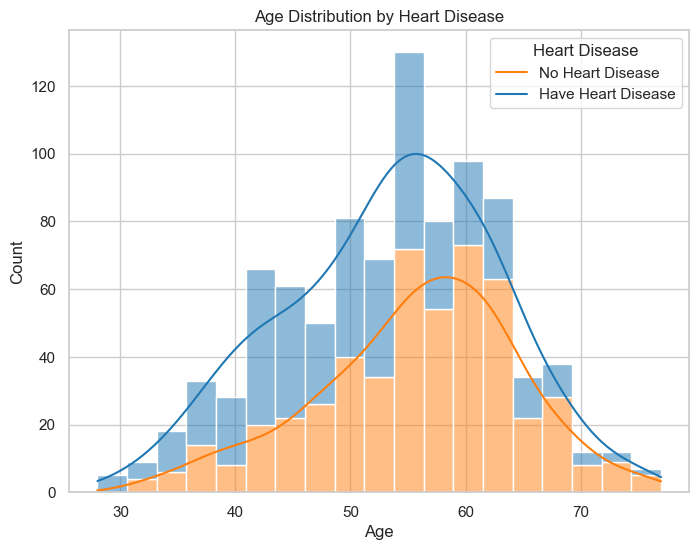

In [876]:
#Create a histogram plot for Age and HeartDisease
plt.figure(figsize=(8, 6))
sns.histplot(data=data, x='Age', hue='HeartDisease', multiple='stack', palette='tab10', kde=True)

#Add title and labels
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Heart Disease', labels=['No Heart Disease', 'Have Heart Disease'])

#Show the plot
plt.show()

**Comment:** Based on the histogram and corresponding density curves for each group, it is observed that
1. Patients with CDVs (in blue) tend to cluster around the age of 50 to 60 as it has the highest number of heart disease cases in regards to `Age` condition. This decreases as people go pass their 60s, despite some significant number are still recorded beyond this age. Meanwhile, younger people below the age of 40 are less likely to experience this health issue.
2. Regarding patients tend to be without heart disease, a roughly similar pattern can be seen as there is a peak around age 55 to 60 in this group although with smaller numbers compared to those with CDVs. Additionally, its distribution is more left-skewed, further strengthening the claim that heart disease is less common in younger adults.

Ultimately, this graph highlights that **middle-aged individuals are at higher risk of experiencing cardiovascular conditions** (fewer patients without heart disease compared to those having it in this age group), and there is a considerable number of cases for those who have already been above 60 years old. This suggests that more interventions should be focused on this population.

## Task 2: Data Processing and Model Building

### Step 2.1: Split the dataset into training data and testing data

*<font color="red">Note that the target variable is HeartDisease, while the ratio for splitting the dataset is 80% for training and 20% for testing</font>*

In [881]:
#Specify features and label
X = data.drop(columns = ['HeartDisease'])
y = data['HeartDisease']

#Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 142) #set the test size as 20%

### Step 2.2: Convert categorical features into numerical values using `OrginalEncoder`

In [883]:
#Import OrdinalEncoder library
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder()

#Only encode categorical columns that have not been encoded
categorical_col_encoded = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


#Convert categorical features into numerical values
X_train[categorical_col_encoded] = ord_enc.fit_transform(X_train[categorical_col_encoded])
X_test[categorical_col_encoded] = ord_enc.transform(X_test[categorical_col_encoded])

# Display the shape of training and testing data sets
print("The shape of training data is:", X_train.shape, y_train.shape)
print("The shape of testing data is:", X_test.shape, y_test.shape)

The shape of training data is: (734, 11) (734,)
The shape of testing data is: (184, 11) (184,)


**Comment:** After splitting the data

- The training set of other attributes X_train has 734 rows and 11 columns, while the target variable `HeartDisease`, represented as y_train, has the same number of sample values as X_train, corresponding to its number of target labels. This indicates that the model learns from these 734 samples using other 11 features to learn patterns and predict the relationship between those and the heart disease label.
- The testing set of remaining attributes X_test has 184 rows and the same number of feature columns (11). Similarly, the corresponding y_test contains the same number of labels as its respective X_test to evaluate the model's ability to predict whether a patient has CDVs based on features it learned from the training data.

### Step 2.3: Build Logistic Regression Model

**[2.3.1] Train Logistic Regression Model**

In [887]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

LogisticRegression()

**[2.3.2] Report two classification performance metrics on the testing data**

In [889]:
#Predict the testing data from the logistic regression model
predicted_test = logreg.predict(X_test)

#Present two classification performance metrics from the predicted testing data
accuracy_predicted_test = accuracy_score(y_test, predicted_test)
f1_predicted_test = f1_score(y_test, predicted_test)

#Display these metrics
print("Accuracy on testing data is:", accuracy_predicted_test)
print("F1-score on testing data is:", f1_predicted_test)

Accuracy on testing data is: 0.842391304347826
F1-score on testing data is: 0.8557213930348259


**[2.3.3] Report two classification performance metrics on the training data**

In [891]:
#Predict the training data
predicted_train = logreg.predict(X_train)

#Report two classification performance metrics
accuracy_predicted_train = accuracy_score(y_train, predicted_train)
f1_predicted_train = f1_score(y_train, predicted_train)

#Display these metrics
print("Accuracy on training data is:", accuracy_predicted_train)
print("F1-score on training data is:", f1_predicted_train)

Accuracy on training data is: 0.8555858310626703
F1-score on training data is: 0.8710462287104623


**Comment:** Based on the above two results regarding performance metrics on Logistic Regression Model
1. <ins>*Accuracy*</ins>:
    - These scores from the model for both training data (85.6%) and testing data (84.3%) are relatively close.
    - This indicates that the model is generalising well to identify patterns and relationships between the target label `HeartDisease` and other attributes, both numerical and categorical, across the splitted datasets. This well performance shows that the model is not simply memorising training data for its testing outcome.
2. <ins>*F1-Score*</ins>:
    - Similarly, the F1-scores are comparably close between training and testing data (0.871 and 0.856 respectively).
    - A small difference of 1.5% drop from training to testing data suggests that the model is able to detect heart disease cases correctly. Since this metric is used to evaluate the confusion matrix between actual and predicted class for precision (the proportion of accurate positive heart disease predictions) and recall (the proportion of actual heart disease cases that are predicted accurately), this good performance also shows the model's capability of avoiding false positives.
  
Since there is only a minimal drop-off in performance on unseen data for both metrics, **this model is not overfitting**. It successfully generalises and captures underlying patterns well to the new data, which is crucial for data related to healthcare contexts due to potentially serious consequences for missing true cases of heart diseases.

**[2.3.4] Perform recursive feature elimination (RFE) technique to identify the effective features**

In [894]:
#Identify the range of the number of eliminated features
num_feat = X_train.shape[1] #Using index 1 for columns

#Define different lists to store respective eliminated features with each corresponding performance metric
eliminated_feat = []
accuracy_list = []
f1_list = []

#Perform the RFE technique for different numbers of eliminated features
for feature in range(1, num_feat + 1):
    rfe = RFE(logreg, n_features_to_select = feature)
    rfe.fit(X_train, y_train)

#Predict the testing data
    predicted = rfe.predict(X_test)

#Report two classification performance metrics
    accuracy = accuracy_score(y_test, predicted)
    f1 = f1_score(y_test, predicted)

#Store the metrics results into respective lists
    eliminated_feat.append(num_feat - feature)
    accuracy_list.append(accuracy)
    f1_list.append(f1)

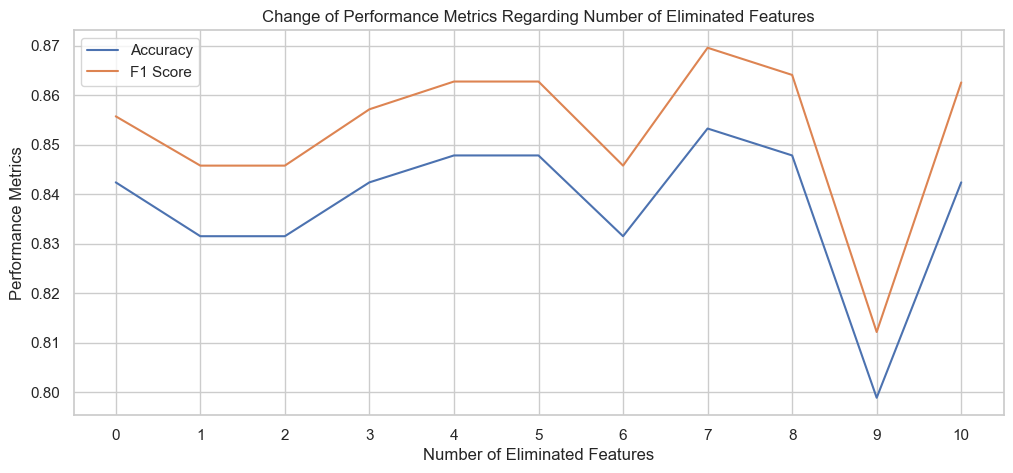

In [895]:
#Visualise the performance of two parameters in regards to the number of eliminated features
plt.figure(figsize=(12,5))
plt.plot(eliminated_feat, accuracy_list, label = 'Accuracy')
plt.plot(eliminated_feat, f1_list, label = 'F1 Score')
plt.xticks(eliminated_feat)
plt.xlabel('Number of Eliminated Features')
plt.ylabel('Performance Metrics')
plt.title('Change of Performance Metrics Regarding Number of Eliminated Features')
plt.grid(True)
plt.legend()
plt.show()

**Comment**: After conducting RFE technique, the above chart visualises the change in performance metrics of the model as more attributes are eliminated from the dataset.

- It is observed that both *Accuracy* and *F1-Score* follow a similar pattern when features are progressivly removed.
- At the start, when all features are retained, the performance for both these metrics are reflected through the above outcomes for testing data before executing RFE technique, which are 84.3% and 0.856 respectively.
- Some fluctuations have been experienced for both *Accuracy* and *F1-Score*
    - A slight dip when 1 or 2 features are eliminated, and then improving from the 3rd to the 5th feature
    - A noticeable drop is seen at 6 features being eliminated before reaching its highest point at the 7th feature.
    - A sharp performance decline at the 9th feature where both metrics plummet drastically to their lowest values, which suggests that by this point, most of the critical features have been removed, therefore, a poor-performing model is expected.

From the graph above, **the best number of eliminated features is 7** as it gives the greatest balance where *Accuracy* and *F1-Score* approximate levels are 87% and 0.853 respectively. This number ensures both metrics still perform predictions well without sacrificing much performance. Throughout the chart, it is crucial to understand the importance of carefully selecting features to be retained, especially those being seen as key attributes

In [897]:
#Define the best value that maximises performance and minimises features
optimal_eliminated_feat = 7

#Perform the RFE technique with the chosen number of eliminated features
rfe = RFE(logreg, n_features_to_select = num_feat - optimal_eliminated_feat)
rfe.fit(X_train, y_train)

#Define the retained features
retained_feat = X_train.columns[rfe.support_] 
#rfe.support_ is a boolean mask to define which features were selected as the most important ones 
retained_feat

Index(['Sex', 'FastingBS', 'ExerciseAngina', 'ST_Slope'], dtype='object')

**Comment**: After selecting the optimal number of features to be eliminated (7), retained features now sit at 4 in total, which are `Sex`, `FastingBS`, `ExerciseAngina` and `ST_Slope`. These are features that are claimed to be critical indicators for heart disease predictions.

**[2.3.5] Recalculate two performance metrics for the best logistic regression models using retained features**

In [900]:
#Set the new train and test variables with respect to retained features
X_train_logreg = X_train[retained_feat]
X_test_logreg = X_test[retained_feat]

logreg.fit(X_train_logreg, y_train)

#Predict the testing data from the logistic regression model
predicted_test_logreg = logreg.predict(X_test_logreg)

#Present two classification performance metrics from the predicted testing data
best_accuracy_logreg = accuracy_score(y_test, predicted_test_logreg)
best_f1_logreg = f1_score(y_test, predicted_test_logreg)

#Display these metrics
print("Accuracy on testing data is:", best_accuracy_logreg)
print("F1-score on testing data is:", best_f1_logreg)

Accuracy on testing data is: 0.8532608695652174
F1-score on testing data is: 0.8695652173913043


**Comment**: Using retained features to retrain the dataset, the performance metrics on testing data show improvements as the scores are relatively higher (85.3% for *Accuracy* and 0.87 for *F1-Score*). This case is called **the best logistic regression model**, where it predicts and generalises the new data most accurately.

### Step 2.4: Build K-NN Classifier

**[2.4.1] Use grid search and k-fold cross validation to report two performance metric**

*<font color="red">Note that K run in range (1, 30), both inclusive, and set k-fold CV equals to 5</font>*

In [904]:
#Define train and test data for the KNN model based on retained features
X_train_KNN = X_train[retained_feat]
X_test_KNN = X_test[retained_feat]

#Identify the range of K
grid_parameter = {'n_neighbors': range(1,31)} #K runs from 1 to 30 inclusively

#Initialise the KNN model
KNN_model = KNeighborsClassifier()

#Perform grid search with 5-fold cross-validation 
#cross-validation is used to test on different subsets of data
grid_search = GridSearchCV(KNN_model, grid_parameter, cv = 5, scoring = 'accuracy') #set cross-validation parameters to 5
#set accuracy as scoring based on the problem statement of testing how accurate this model is in predicting heart disease conditions
grid_search.fit(X_train_KNN, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 31)}, scoring='accuracy')

In [905]:
#Obtain mean test scores from the grid search results
mean_test_scores = grid_search.cv_results_['mean_test_score']

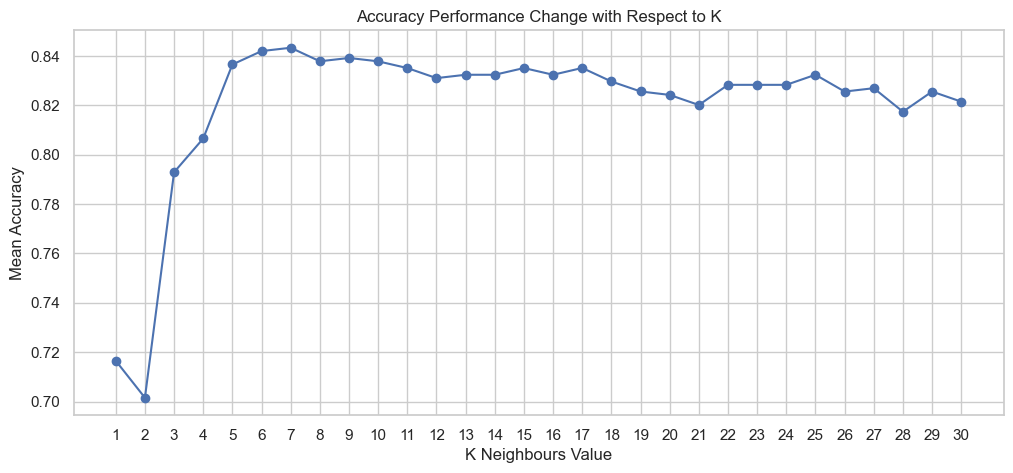

In [906]:
#Plot the performance change regarding K
plt.figure(figsize=(12,5))
plt.plot(grid_parameter['n_neighbors'], mean_test_scores, marker = 'o')
plt.xticks(grid_parameter['n_neighbors'])
plt.xlabel('K Neighbours Value')
plt.ylabel('Mean Accuracy')
plt.title('Accuracy Performance Change with Respect to K')
plt.grid(True)
plt.show()

**Comment:** The above chart highlights the accuracy performance when changing the number of neighbours (K) and hoe it impacts the model's ability to predict heart disease conditions correctly. From this figure, some key insights are listed as below
- The lowest accuracy value is at K = 2 (70%), even worst than when the model only takes 1 neighbour to rely on for predictions (roughly 72%). This suggests that the model maybe overfitting with just one or two neighbour, and it is struggling to generalise the training data well.
- As K increases from 3 onwards, there is a significant increment in accuracy rate, indicating that the model benefits from having more neighbours to learn and evaluate for predictions.
- Since then, the accuracy level has achieved its optimal performance in the range of 5 to 9 (central around 84%), **with its peak at K = 7**, before slightly declining when K > 9 but remaining relatively consistent and stable. This means that the model becomes more generalised, considering more neighbours are taken into account for predictions.
- However, when there are too many neighbours being considered, the accuracy rates shows a slightly gradual downward trend (82-83%) as there might be some noises, outlier variances and biases, leading to less accurate distinctions.

As a result, K = 7 should be chosen to balance accuracy and generalisation in heart disease prediction.


**[2.4.2] Identify the best case of KNN model**

In [909]:
#Identify the best K
best_K = grid_search.best_params_['n_neighbors']
best_accuracy = grid_search.best_score_

#Train the model with the best K
best_KNN = KNeighborsClassifier(n_neighbors = best_K)
best_KNN.fit(X_train_KNN, y_train)

KNeighborsClassifier(n_neighbors=7)

In [910]:
#Predict the testing data
predicted_best_KNN = best_KNN.predict(X_test_KNN)

#Calculate the performance metrics on the testing data
best_accuracy_KNN = accuracy_score(y_test, predicted_best_KNN)
best_f1_KNN = f1_score(y_test, predicted_best_KNN)

#Display the results
print("Best K:", best_K)
print("Accuracy of the testing data with best K is", best_accuracy_KNN)
print("F1-score of the testing data with best K is", best_f1_KNN)

Best K: 7
Accuracy of the testing data with best K is 0.8532608695652174
F1-score of the testing data with best K is 0.8682926829268293


In [911]:
#Predict the trainng data
predicted_train_KNN = best_KNN.predict(X_train_KNN)

#Calculate the performance metrics on the testing data
accuracy_train_KNN = accuracy_score(y_train, predicted_train_KNN)
f1_train_KNN = f1_score(y_train, predicted_train_KNN)

#Display the results
print("Accuracy of the training data with best K is", accuracy_train_KNN)
print("F1-score of the training data with best K is", f1_train_KNN)

Accuracy of the training data with best K is 0.8501362397820164
F1-score of the training data with best K is 0.8674698795180723


**Comment**: The above outcomes for two performance metrics on best KNN model shows that
1. <ins>*Accuracy*</ins>
    - The scores for both training and testing data are almost equally well (85% and 85.3% respectively)
    - There seems to be no significant effect on the testing data from the already-learned training data, suggesting the model is generalising well to unseen data and hidden patterns.
2. <ins>*F1-Score*</ins>
     - Similarly, only 0.1% difference in the result of F1-Score between training and testing data is observed (0.867 and 0.868 respectively).
     - This indicates that the model slightly increases its performance and maintains a good balance between precision and recall for these two splitted datasets.
  
Overall, **the model is well-suited for heart disease predictions** as it has learned meaningful patterns in the data rather than simply memorising values and results from training set to perform on the testing data. It is reliable to make predictions for new patients who are yet to be included in this dataset, which is crucial for the healthcare setting to prevent missed diagnoses or false positives. The model therefore is not overfitting and can be trusted to predict accurately.

## Task 3: Compare 2 models: KNN Classifier & Logistic Regression

**[3.1] Display performance metric results in a table format**

In [915]:
list_models = ['KNN', 'Logistic Regression']
list_accuracy = [best_accuracy_KNN, best_accuracy_logreg]
list_f1 = [best_f1_KNN, best_f1_logreg]

#Create a DataFrame
results = pd.DataFrame({
    'Model': list_models,
    'Accuracy': list_accuracy,
    'F1-Score': list_f1
})

# Visualize the table
results.style.set_caption("Performance Comparison of KNN and Logistic Regression")

,Model,Accuracy,F1-Score
0,KNN,0.853261,0.868293
1,Logistic Regression,0.853261,0.869565


**Comment**: Looking at two performance metrics from both models, it can be observed
- Both **KNN** and **Logistic Regression** models achieve an identical *Accuracy* level of 85.33%, which is a relatively high number. This suggests that they are equally capable of accurately predicting whether a patient has heart disease in 85.33% of the cases.
- In terms of *F1-score*, since that level of **Logistic Regression** is slightly higher than **KNN classifier** (0.869 vs. 0.868 respectively, it gives the former model *a slim edge* over the latter. This indicates that Logistic Regression may have a marginally better balance between precision and recall than the KNN model.

Overall, **both models perform nearly identically, and no significant difference in performance is claimed**. Since KNN is non-parametric, it may suit for more complex and non-linear data. Meanwhile, the Logistic Regression model assumes a direct linear relationship between the target label `HeartDisease` and other attributes, resulting in faster predictions and easier interpretations. This may be a crucial factor in slightly giving an advantage to this model, given the healthcare setting where quick computational efficiency is prioritised.

**[3.2] Compare two models using a Confusion Matrix**

Text(788.8409090909089, 0.5, 'True Values')

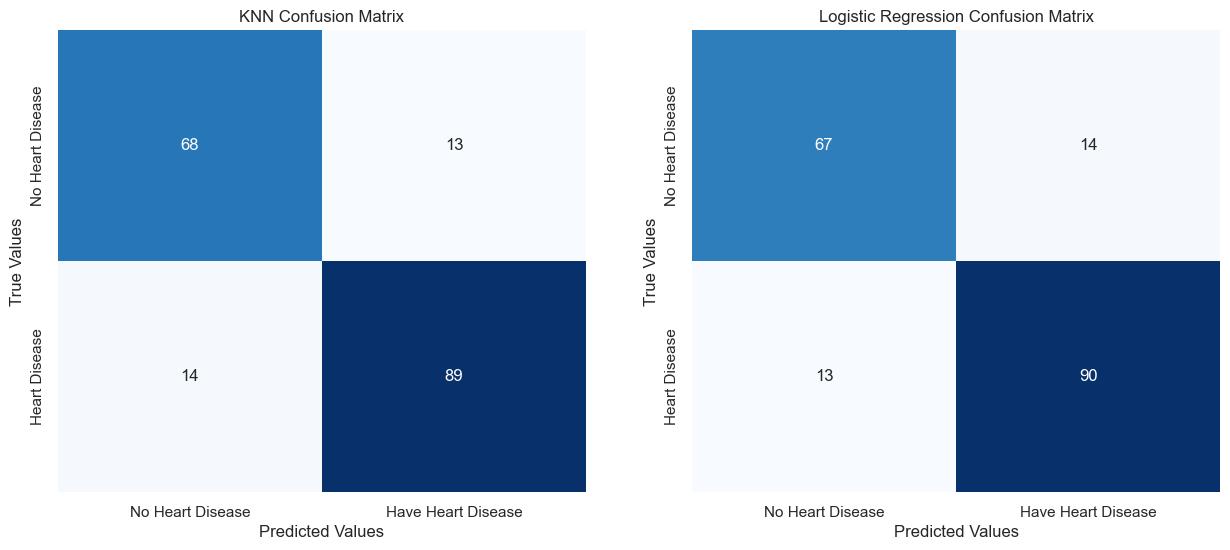

In [918]:
from sklearn.metrics import confusion_matrix

#Generate confusion matrices for both models
knn_conf_matrix = confusion_matrix(y_test, predicted_best_KNN)
logreg_conf_matrix = confusion_matrix(y_test, predicted_test_logreg)

#Plot the confusion matrices side by side
plt.figure(figsize=(15, 6))

#Subplot 1
plt.subplot(1, 2, 1)
sns.heatmap(knn_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Heart Disease', 'Have Heart Disease'], yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')

# Subplot 2: Confusion Matrix for Logistic Regression
plt.subplot(1, 2, 2)
sns.heatmap(logreg_conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['No Heart Disease', 'Have Heart Disease'], yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')

**Comment**: Based on the two confusion matrices above of both models to evaluate their balance between precision and recall
1. <ins>No Heart Disease, Correct Prediction (True Negatives - TN)</ins>: KNN is slightly better in predicting patients without heart diseases than Logistic Regressions by 1 patient (68 vs. 67)
2. <ins>Incorrectly Predicted Having CDVs (False Positives - FP)</ins>: KNN has a slightly lower FP rate at 13 patients, compared to 14 of Logistic Regression. This means that the former model has a marginally lower rate of unnecessary CDVs diagnoses and treatments.
3. <ins>Incorrectly Predicted NOT Having CDVs (False Negatives - FN)</ins>: In contrast, Logistic Regression performs better in not missing heart disease cases by one fewer patient compared to KNN (13 vs. 14). This is critical as failing to diagnose heart disease patients for treatment is a critical risk in healthcare.
4. <ins>Correctly Predicted Having Heart Disease (True Positives - TP)</ins>: Similarly to FN rate, Logistic Regression has a marginally higher performance in predicting patients with CDVs as it discovers one more true cases compared to KNN (90 vs. 89).

Given the context of how accurately the model could predict whether a patient has heart disease or not, **the Logistic Regression model edges out KNN Classifier slightly** as it performs better to ensure missing fewer patients with this health issue. This result is similar to the comparison of the table above.

**[3.3] Evaluate the performance of these two models using Area Under ROC curve (AUC)**

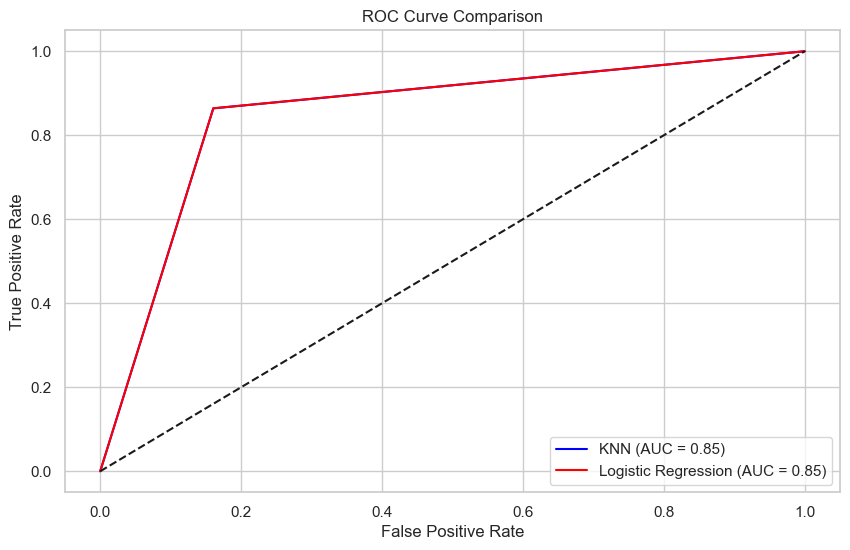

In [921]:
from sklearn.metrics import roc_curve, roc_auc_score

#Compute ROC curve and AUC for KNN
knn_fpr, knn_tpr, _ = roc_curve(y_test, predicted_best_KNN)
knn_auc = roc_auc_score(y_test, predicted_test_logreg)

#Compute ROC curve and AUC for Logistic Regression
log_reg_fpr, log_reg_tpr, _ = roc_curve(y_test, predicted_best_KNN)
log_reg_auc = roc_auc_score(y_test, predicted_test_logreg)

#Plot the ROC curve for both models
plt.figure(figsize=(10, 6))

#ROC curve for KNN
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC = {knn_auc:.2f})', color='blue')

#ROC curve for Logistic Regression
plt.plot(log_reg_fpr, log_reg_tpr, label=f'Logistic Regression (AUC = {log_reg_auc:.2f})', color='red')

#Plot the baseline (random guess)
plt.plot([0, 1], [0, 1], 'k--')

#Add labels and title
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

#Show the plot
plt.show()

**Comment** The ROC curve figure plots the true positive rate against the false negative rate with the AUC to examine the model's ability to distinguish between two different classes (having heart disease vs. no CDVs). From this chart, it can be observed that
1. <ins>*ROC Curves*</ins>
    - Both KNN and Logistic Regression follow identical paths, as there is not a visible distinction between these two models, especially when the blue line representing KNN seems to match with the red line of the latter model.
    - Both curves are well aboved the dashed diagonal line, which represents the prediction of the dataset before running any model, or in other words, chance/random guessing. They are also capable of maintaing high true positive rates while keeping false negative ones low.
2. <ins>*AUC Statistics*</ins>
    - Both models have equal predictive power, as their AUC score is the same (0.85). This shows that they both perform strongly in classifying two classes, indicating that each model will accurately predict patients with CDVs higher than patients without heart disease at a chance of 85%. This is much better than random guessing at a 50% rate.
    - When evaluating all possible classification thresholds and methods, neither model shows a significant and clear edge over the other. This suggests that to select the most suitable model, other external factors should be considered, such as model complexity, prediction speed and interpretation capability.
  
Thus, the result of this comparative technique (ROC curve and AUC) should be combined with the above two outcomes to conclude. Ultimately, it can be claimed that **the models perform well to accurately predict whether a patient has heart disease or not**.

#### Conclusion

After using 3 different methods to compare the performance of both Logistic Regression and KNN models, despite all performing equally well, it is recommended that **Logistic Regression model should be utilised to ensure patients with CDVs receive accurate diagnoses and timely treatment** given the nature of its fast prediction and ease of use from a computational efficiency perspective.